In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos de estaciones en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Viento/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
1,7,KARLSTAD-AIRPORT,SE,+59:26:40,+013:20:15,107
2,11,KREMSMUENSTER (TAWES),AT,+48:03:18,+014:07:51,382
3,12,GRAZ-UNIVERSITAET,AT,+47:04:40,+015:26:56,367
4,13,INNSBRUCK-UNIV,AT,+47:15:36,+011:23:03,578
...,...,...,...,...,...,...
6222,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
6223,27905,MONTE CESEN,IT,+45:56:43,+012:01:14,1552
6224,27912,MONTE VERENA,IT,+45:55:50,+011:24:50,2008
6225,27940,BARKALD,NO,+61:59:30,+010:53:11,452


In [3]:
#Filtrado de datos para Italia
metadata_IT=metadata[metadata.CN=='IT']
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
52,170,FERRARA,IT,+44:49:57,+011:37:15,15
53,171,GENOA,IT,+44:24:52,+008:55:35,55
54,176,ROMA CIAMPINO,IT,+41:46:59,+012:34:59,105
277,892,PASSO ROLLE,IT,+46:17:49,+011:47:15,199
278,897,LAVIS,IT,+45:59:17,+011:06:50,230
...,...,...,...,...,...,...
6220,27896,ROSA',IT,+45:43:00,+011:46:35,88
6221,27902,VALLI DEL PASUBIO,IT,+45:45:28,+011:12:48,602
6222,27904,VICENZA - SANT'AGOSTINO,IT,+45:31:27,+011:31:13,29
6223,27905,MONTE CESEN,IT,+45:56:43,+012:01:14,1552


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_IT['LAT'] = metadata_IT['LAT'].apply(dms_a_decimal)
metadata_IT['LON'] = metadata_IT['LON'].apply(dms_a_decimal)
metadata_IT.head()

,STAID,STANAME,CN,LAT,LON,HGHT
52,170,FERRARA,IT,44.832500,11.620833,15
53,171,GENOA,IT,44.414444,8.926389,55
54,176,ROMA CIAMPINO,IT,41.783056,12.583056,105
277,892,PASSO ROLLE,IT,46.296944,11.787500,199
278,897,LAVIS,IT,45.988056,11.113889,230


In [6]:
#Carga de mapas para obtener mapa de Italia
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
italia = world[world["name"] == "Italy"] #Mapa de Italia

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_IT['LON'], metadata_IT['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_IT, geometry=estaciones, crs="EPSG:4326") 

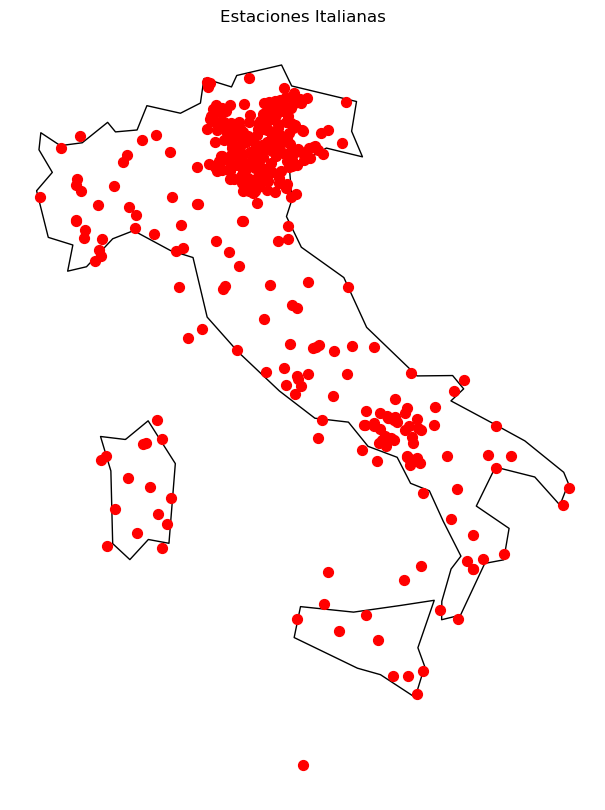

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones italianas
lista_estaciones_italianas=metadata_IT.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='FG_STAID000000'
station_i=station[:-len(str(lista_estaciones_italianas[0]))]+str(lista_estaciones_italianas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Viento/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9) & (data.DATE<'2025-01-01')]
data_unif=data.loc[:,['DATE','FG']]
data_unif.set_index('DATE', inplace=True)
data_unif

,FG
DATE,
2008-01-01,0
2008-01-02,15
2008-01-03,29
2008-01-04,27
2008-01-05,13
...,...
2024-12-26,20
2024-12-27,20
2024-12-28,40


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_italianas[1:]:
    station='FG_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Viento/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_FG!=9)]
    df=data.loc[:,['DATE','FG']]
    df.set_index('DATE', inplace=True)
    data_unif['FG '+str(i)]=df

data_unif

,FG,FG 171,FG 176,FG 892,FG 897,FG 925,FG 1666,FG 1668,FG 1672,FG 1673,...,FG 27890,FG 27891,FG 27892,FG 27894,FG 27895,FG 27896,FG 27902,FG 27904,FG 27905,FG 27912
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,0,17.0,32,18.0,NaN,20,0.0,7.0,29,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,15,43.0,19,15.0,NaN,19,37.0,14.0,24,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN
2008-01-03,29,89.0,38,41.0,NaN,32,12.0,23.0,15,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,NaN,NaN
2008-01-04,27,112.0,29,40.0,NaN,25,12.0,20.0,9,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2008-01-05,13,61.0,41,54.0,NaN,41,15.0,9.0,11,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-26,20,NaN,33,36.0,NaN,43,NaN,15.0,30,NaN,...,13.0,15.0,15.0,14.0,15.0,12.0,NaN,8.0,10.0,40.0
2024-12-27,20,NaN,21,21.0,NaN,31,43.0,11.0,25,6.0,...,10.0,11.0,15.0,11.0,14.0,18.0,NaN,6.0,8.0,49.0
2024-12-28,40,NaN,17,21.0,NaN,23,NaN,7.0,24,NaN,...,13.0,10.0,14.0,10.0,13.0,10.0,NaN,5.0,7.0,57.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen datos faltantes y se renombra la primera estación con el ID de estación
d=data_unif.dropna(axis=1)
d=d.rename({'FG':'FG '+str(lista_estaciones_italianas[0])},axis=1)
d

,FG 170,FG 176,FG 925,FG 1672,FG 1712,FG 1720,FG 1723,FG 1740,FG 1748,FG 2074,...,FG 23010,FG 23781,FG 23784,FG 23789,FG 27782,FG 27799,FG 27806,FG 27832,FG 27836,FG 27840
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,0,32,20,29,9,14,15,15,23,14,...,51,8,20,52,14,14,15,15,15,8
2008-01-02,15,19,19,24,7,19,20,17,17,15,...,32,15,19,31,19,19,29,29,29,15
2008-01-03,29,38,32,15,10,26,13,25,41,15,...,39,32,13,55,26,26,40,40,40,32
2008-01-04,27,29,25,9,19,22,15,35,28,27,...,33,26,20,40,22,22,38,38,38,26
2008-01-05,13,41,41,11,7,15,10,20,11,7,...,54,20,16,37,15,15,25,25,25,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-26,20,33,43,30,23,20,24,31,22,16,...,76,17,23,52,20,13,15,14,26,17
2024-12-27,20,21,31,25,21,19,21,20,22,13,...,54,13,23,21,19,11,13,11,21,13
2024-12-28,40,17,23,24,21,8,17,19,24,16,...,43,8,24,20,8,10,9,6,13,8


In [13]:
# Estaciones italianas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_IT[metadata_IT.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
52,170,FERRARA,IT,44.832500,11.620833,15
54,176,ROMA CIAMPINO,IT,41.783056,12.583056,105
282,925,PAGANELLA,IT,46.150000,11.033056,2125
653,1672,PESCARA,IT,42.430000,14.200000,11
662,1712,MILANO MALPENSA,IT,45.616667,8.733056,211
668,1720,TREVISO/ISTRANA,IT,45.683056,12.100000,41
669,1723,RONCHI DEI LEGIONARI,IT,45.816667,13.483056,10
675,1740,FRONTONE,IT,43.516667,12.733056,570
681,1748,DECIMOMANNU,IT,39.350000,8.966667,23
724,2074,TURIN/CASALLE,IT,45.220000,7.650000,301


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

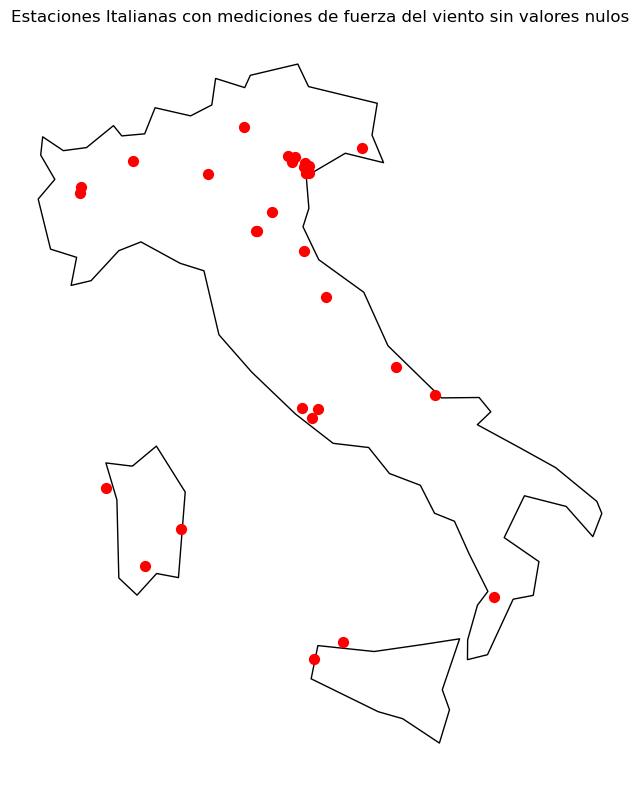

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_it=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_it['LON'],mt_it['LAT'],mt_it['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_IT=mt_it[mt_it.STAID.isin(ww)]
mt_IT

,STAID,STANAME,CN,LAT,LON,HGHT
52,170,FERRARA,IT,44.832500,11.620833,15
54,176,ROMA CIAMPINO,IT,41.783056,12.583056,105
282,925,PAGANELLA,IT,46.150000,11.033056,2125
653,1672,PESCARA,IT,42.430000,14.200000,11
662,1712,MILANO MALPENSA,IT,45.616667,8.733056,211
668,1720,TREVISO/ISTRANA,IT,45.683056,12.100000,41
669,1723,RONCHI DEI LEGIONARI,IT,45.816667,13.483056,10
675,1740,FRONTONE,IT,43.516667,12.733056,570
681,1748,DECIMOMANNU,IT,39.350000,8.966667,23
724,2074,TURIN/CASALLE,IT,45.220000,7.650000,301


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_IT['LON'], mt_IT['LAT'])] 
puntos = gpd.GeoDataFrame(mt_IT, geometry=estaciones, crs="EPSG:4326") 

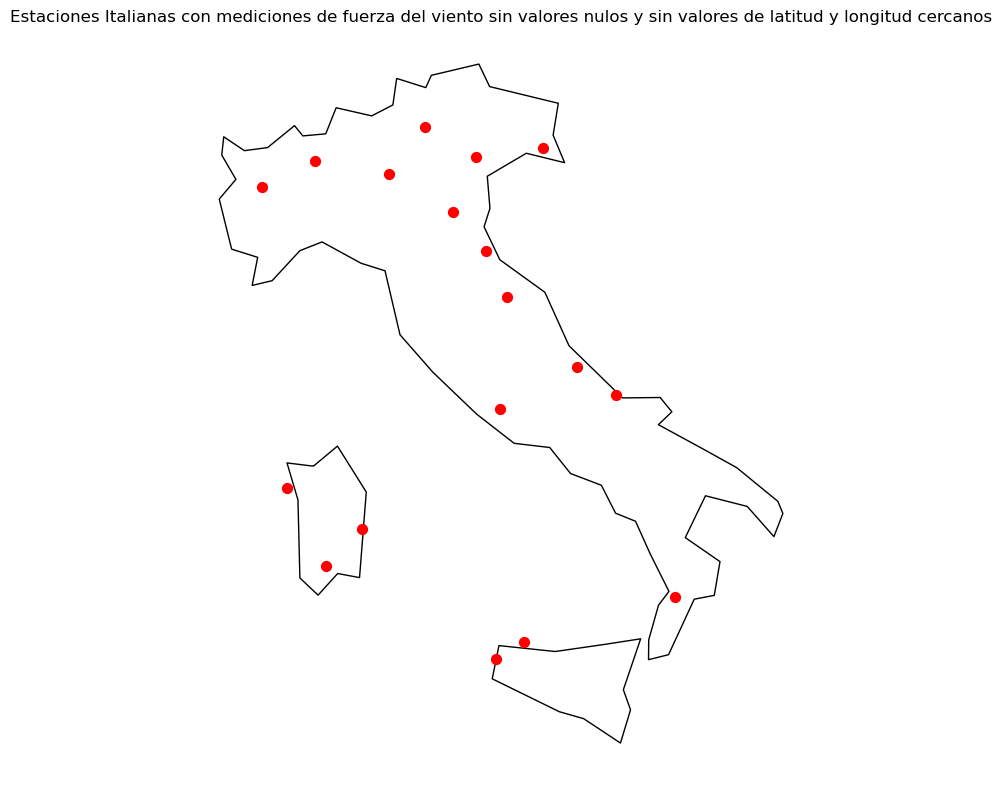

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['FG '+str(i) for i in mt_IT.STAID.to_list()]]
data=data.resample('MS').mean()
data

,FG 170,FG 176,FG 925,FG 1672,FG 1712,FG 1720,FG 1723,FG 1740,FG 1748,FG 2074,FG 2078,FG 2101,FG 2109,FG 3007,FG 16402,FG 17289,FG 17587,FG 23010
DATE,,,,,,,,,,,,,,,,,,
2008-01-01,10.483871,23.935484,35.709677,17.129032,10.645161,13.161290,10.903226,28.677419,23.935484,14.838710,16.870968,40.387097,42.935484,42.354839,55.193548,36.903226,19.580645,47.129032
2008-02-01,10.827586,22.482759,36.689655,22.310345,9.655172,12.965517,14.586207,24.448276,23.896552,13.310345,15.379310,38.827586,40.793103,45.241379,48.517241,30.482759,21.896552,48.827586
2008-03-01,17.258065,28.419355,52.838710,26.838710,17.612903,22.741935,25.064516,46.322581,41.193548,23.096774,25.258065,51.193548,50.774194,36.387097,63.064516,40.935484,31.838710,60.387097
2008-04-01,11.366667,40.700000,44.133333,31.433333,18.400000,19.233333,17.700000,44.633333,36.000000,21.366667,23.466667,48.066667,55.300000,46.766667,60.733333,41.033333,26.566667,51.233333
2008-05-01,14.000000,25.354839,37.000000,20.129032,13.967742,18.935484,19.290323,27.000000,43.096774,21.483871,23.838710,45.645161,38.806452,28.548387,51.516129,42.387097,23.548387,43.032258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,4.136364,26.272727,28.909091,26.863636,25.636364,18.909091,22.727273,14.045455,34.863636,19.227273,21.636364,34.636364,33.818182,30.409091,36.818182,31.590909,27.681818,40.500000
2024-09-01,9.409091,29.227273,50.772727,29.681818,28.727273,25.181818,26.454545,27.681818,35.363636,19.818182,25.363636,45.409091,50.090909,32.136364,53.909091,35.090909,33.500000,49.318182
2024-10-01,7.724138,24.896552,38.000000,22.758621,21.137931,21.965517,19.344828,23.275862,30.896552,16.344828,21.275862,37.551724,43.241379,28.620690,44.103448,40.655172,26.586207,36.000000


In [21]:
#Cálculo de la media para cada mes en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'FG'},axis=1)
a

,FG
DATE,
2008-01-01,27.265233
2008-02-01,26.729885
2008-03-01,36.734767
2008-04-01,35.451852
2008-05-01,29.865591
...,...
2024-08-01,26.593434
2024-09-01,33.729798
2024-10-01,28.021073


In [22]:
#Exportación de datos mensuales de la velocidad del viento en Italia
a.to_csv('viento_mensual_ita.csv',index=True,encoding='utf-8')

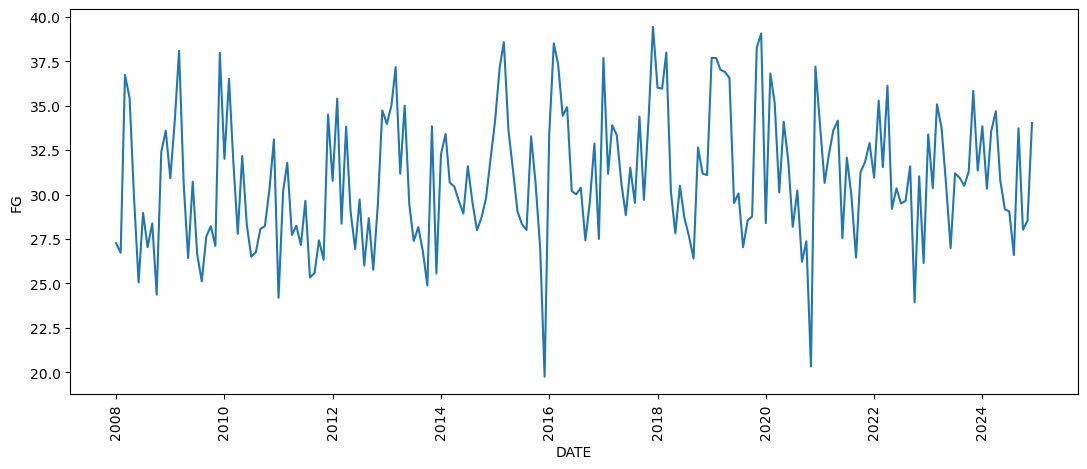

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.FG)
plt.xticks(rotation=90)
plt.show()